In [1]:
!pip install -q xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay
)
df = pd.read_csv("CKD_preprocessed_patient_level.csv")
TARGET = "CKD (1-yes, 0-no)"

if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' not found.")
if "Patient ID" in df.columns:
    raise ValueError("Patient ID is still present. Remove before modeling.")
if df.isnull().sum().sum() > 0:
    raise ValueError("Missing values detected in the dataset.")


In [3]:
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=2,
    subsample=0.85,
    colsample_bytree=0.85,
    gamma=0,
    reg_alpha=0.01,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)


Training samples: 280
Testing samples : 120


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.85, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=2, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)


XGBOOST RESULTS
Accuracy    : 0.7583
Precision   : 0.7407
Recall      : 0.7273
Specificity : 0.7846
F1 Score    : 0.7339
ROC-AUC     : 0.8613
PR-AUC      : 0.8586

Confusion Matrix:
[[51 14]
 [15 40]]

Classification Report:
              precision    recall  f1-score   support

      No CKD       0.77      0.78      0.78        65
         CKD       0.74      0.73      0.73        55

    accuracy                           0.76       120
   macro avg       0.76      0.76      0.76       120
weighted avg       0.76      0.76      0.76       120



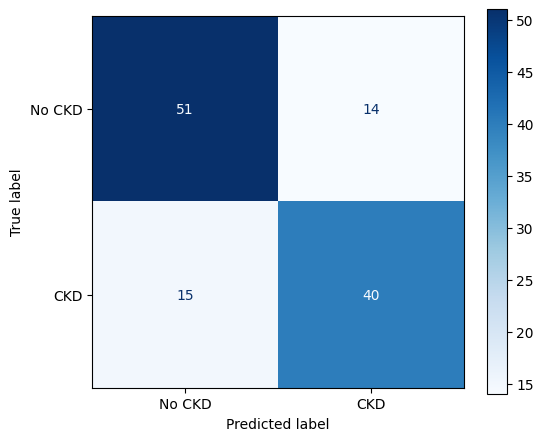

In [4]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

accuracy    = accuracy_score(y_test, y_pred)
precision   = precision_score(y_test, y_pred, zero_division=0)
recall      = recall_score(y_test, y_pred, zero_division=0)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1          = f1_score(y_test, y_pred, zero_division=0)
roc_auc     = roc_auc_score(y_test, y_prob)
pr_auc      = average_precision_score(y_test, y_prob)

print("\n" + "=" * 60)
print("XGBOOST RESULTS")
print("=" * 60)
print(f"Accuracy    : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"F1 Score    : {f1:.4f}")
print(f"ROC-AUC     : {roc_auc:.4f}")
print(f"PR-AUC      : {pr_auc:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                            target_names=["No CKD", "CKD"], zero_division=0))
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["No CKD", "CKD"],
    cmap="Blues", values_format="d", ax=ax
)


<Figure size 640x480 with 0 Axes>

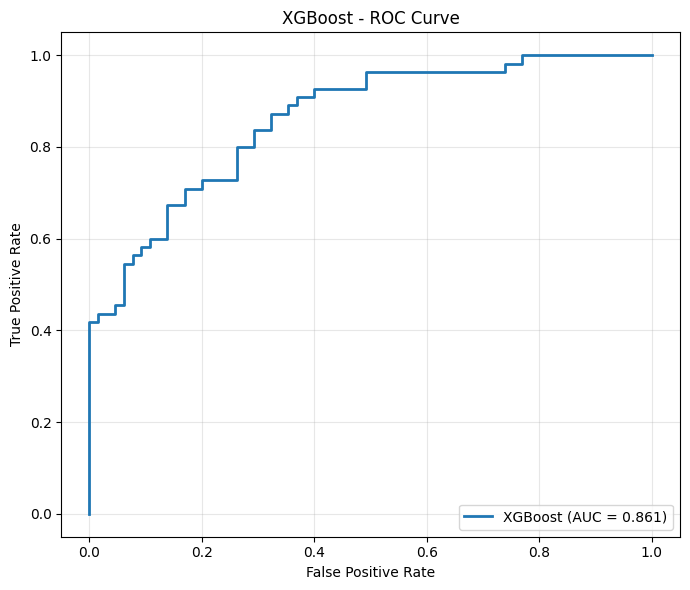

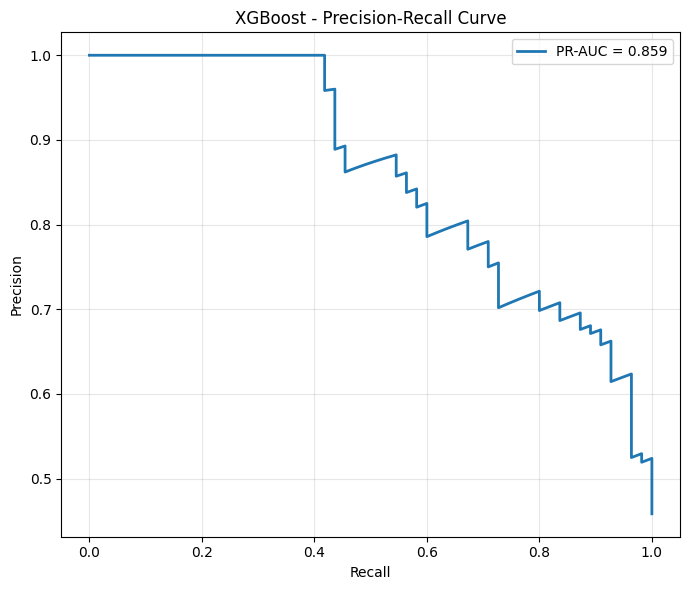

In [5]:
ax.set_title("XGBoost - Confusion Matrix")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, linewidth=2, label=f"XGBoost (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="", linewidth=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("XGBoost - ROC Curve")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(recall_curve, precision_curve, linewidth=2,
        label=f"PR-AUC = {pr_auc:.3f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("XGBoost - Precision-Recall Curve")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()



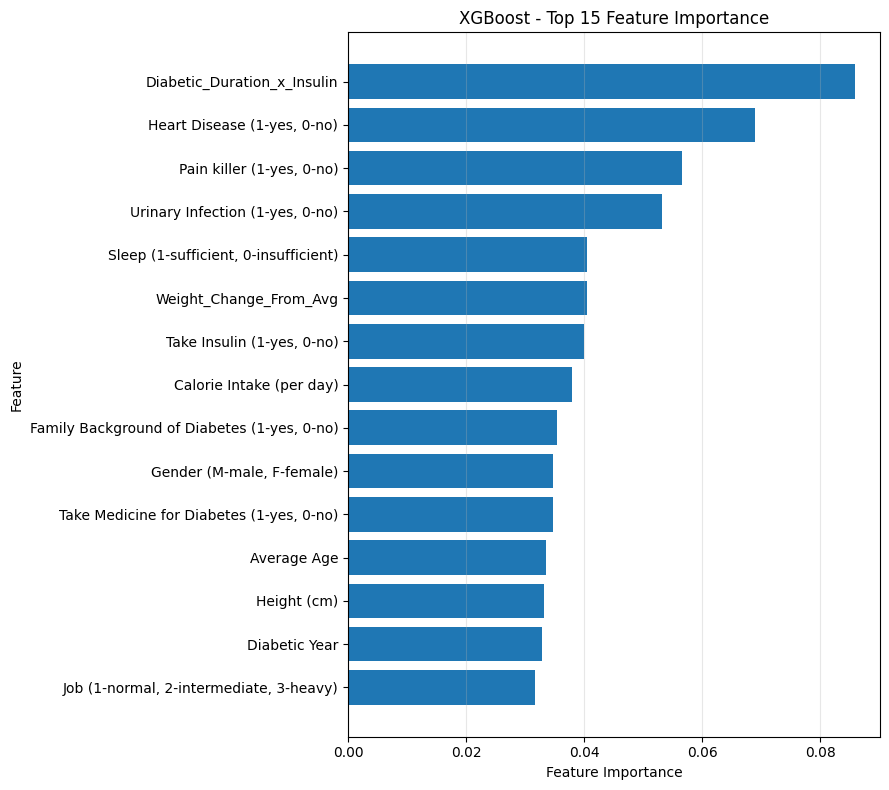


Top 15 XGBoost Features:
                                    Feature  Importance
                Diabetic_Duration_x_Insulin    0.085860
                Heart Disease (1-yes, 0-no)    0.068908
                  Pain killer (1-yes, 0-no)    0.056614
            Urinary Infection (1-yes, 0-no)    0.053247
       Sleep (1-sufficient, 0-insufficient)    0.040562
                     Weight_Change_From_Avg    0.040521
                 Take Insulin (1-yes, 0-no)    0.039978
                   Calorie Intake (per day)    0.038010
Family Background of Diabetes (1-yes, 0-no)    0.035350
                  Gender (M-male, F-female)    0.034787
   Take Medicine for Diabetes (1-yes, 0-no)    0.034654
                                Average Age    0.033550
                                Height (cm)    0.033186
                              Diabetic Year    0.032806
    Job (1-normal, 2-intermediate, 3-heavy)    0.031620


In [6]:

# FEATURE IMPORTANCE

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=True)

top_features = importance.tail(15)

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top_features["Feature"], top_features["Importance"])
ax.set_xlabel("Feature Importance")
ax.set_ylabel("Feature")
ax.set_title("XGBoost - Top 15 Feature Importance")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()
print("\nTop 15 XGBoost Features:")
print(
    importance
    .sort_values("Importance", ascending=False)
    .head(15)
    .to_string(index=False)
)